In [1]:
import sys

sys.path.append('../clientes/')
import clientes as cl

In [2]:
import logging
import tracemalloc

import matplotlib.pyplot as plt
import requests
import seaborn as sns
from dotenv import load_dotenv

In [3]:
r = requests.get(
    "https://clinicaltrials.gov/api/v2/studies",
    params={"query.cond":"epilepsy", "pageSize":300},
    headers={"Accept":"application/json"},
    timeout=30,
)
r.raise_for_status()
clinical_trials = r.json()

In [4]:
'''
# preubas errores
r2 = requests.get(
    "https://clinicaltrials.gov/api/v2/studies?pageSize=20",
    params={"query.cond":"temporal lobe epilepsy","pageSize":25},
    headers={"Accept":"application/json"},
    timeout=30,
)
r2.raise_for_status()
data2 = r2.json()
''';

In [5]:
url = "https://clinicaltrials.gov/api/v2/studies"
n = 300
params = {'query.cond': 'epilepsy',
         'pageSize': n}

tracemalloc.start()
records1 = cl.process_studies_by_generator(url, params, n)
current1, peak1 = tracemalloc.get_traced_memory()
tracemalloc.stop()

print('Usando generador:')
print(f'Peak memory: {peak1/(1024*1024):.3f} MB')

tracemalloc.start()
records2 = cl.process_studies_in_memory(url, params, n)
current2, peak2 = tracemalloc.get_traced_memory()
tracemalloc.stop()

print()
print('Cargando todo en memoria:')
print(f'Peak memory: {peak2/(1024*1024):.3f} MB')

Usando generador:
Peak memory: 54.783 MB

Cargando todo en memoria:
Peak memory: 169.742 MB


In [6]:
records1[1]

{'nctId': 'NCT06082999',
 'briefTitle': 'Gene-STEPS: Shortening Time of Evaluation in Paediatric Epilepsy Services',
 'lastUpdateSubmitDate': '2023-10-11',
 'studyType': 'OBSERVATIONAL'}

In [7]:
records2[1]

{'nctId': 'NCT06082999',
 'briefTitle': 'Gene-STEPS: Shortening Time of Evaluation in Paediatric Epilepsy Services',
 'lastUpdateSubmitDate': '2023-10-11',
 'studyType': 'OBSERVATIONAL'}

In [8]:
extractor = cl.ClinicalTrialsExtractor()
url = "https://clinicaltrials.gov/api/v2/studies"
n = 300
params = {"query.cond": "epilepsy", "pageSize": n}
clinical_trials_data = extractor.process_studies_by_generator(url, params, n)

print(f"extracted {len(clinical_trials_data)} records\n")
print(clinical_trials_data[2])

extracted 300 records

{'nctId': 'NCT00581893', 'briefTitle': 'Phenytoin and Driving Safety: A Randomized, Controlled Cross-Over Study', 'lastUpdateSubmitDate': '2021-06-30', 'studyType': 'INTERVENTIONAL'}


In [9]:
extractor.save_raw(url, params, n, "epilepsy_raw_dump.json")

saved at: ../data/raw/epilepsy_raw_dump.json.json


In [10]:
load_dotenv()

True

In [11]:
drugs = ["cannabidiol", "levetiracetam", "carbamazepine"]
openfda_data = {}
pubmed_data = {}

for drug in drugs:
    openfda_data[drug] = cl.extract_openfda_events(drug_name=drug, limit=100)
    pubmed_query = f"{drug} AND epilepsy"
    pubmed_data[drug] = cl.extract_pubmed_articles(search_term=pubmed_query, max_results=100)

retrieved 100 openfda records for cannabidiol drug
retrieved 100 articles for cannabidiol AND epilepsy query
retrieved 100 openfda records for levetiracetam drug
retrieved 100 articles for levetiracetam AND epilepsy query
retrieved 100 openfda records for carbamazepine drug
retrieved 100 articles for carbamazepine AND epilepsy query


## Validaciones pydantic

__Para los ensayos clinicos:__
- La cantidad de participantes registrados en el estudio no puede ser negativa ni 0
- En un estudio con 'overallStatus' 'completado' no puede haber 0 inscritos porque eso seria un ensayo fallado o retirado, no completado.

In [12]:
logging.basicConfig(
    filename='dropped_clinical_trials.log',
    filemode='w',
    level=logging.WARNING,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

In [13]:
clinical_trials_data = clinical_trials.get("studies", [])
validated_ct = cl.validate_clinical_trials(clinical_trials_data)

Processed 300 records. Kept: 299. Dropped: 1.


Para los eventos adversos de open fda:
- De acuerdo con la documentación de openfda (https://open.fda.gov/apis/drug/event/searchable-fields/), el sexo puede venir marcado como 1 (male), 2 (female) o 0 (unknown). Defini una validacion para deshacerme de los 0s ya que los rangos fisiólogicos de algunas variables dependen del sexo y no conocerlo puede intrpducir artefactos.
- La edad debe estar dentro de un rango fisiologico adecuado (0 - 120 años).
- El peso debe estar dentro de un rango fisiologico adecuado (0.1 - 500 kg).

In [14]:
validated_levetiracetam = cl.validate_adverse_events(openfda_data["levetiracetam"])

Processed 100 records. Kept: 90. Dropped: 10.


In [15]:
validated_cannabidiol = cl.validate_adverse_events(openfda_data["cannabidiol"])

Processed 100 records. Kept: 100. Dropped: 0.


In [16]:
validated_carbamazepine = cl.validate_adverse_events(openfda_data["carbamazepine"])

Processed 100 records. Kept: 80. Dropped: 20.


Para los articulos de pubmed:
- La fecha debe ser coherente (no menor a 1800, no mayor al año actual)
- La fecha debe de tener 4 digitos en el año
- Debe de haber fecha de publicacion

In [17]:
validated_pubmed_cbz = cl.validate_pubmed_articles(pubmed_data["carbamazepine"])

Processed 100 records. Kept: 100. Dropped: 0.


In [18]:
validated_pubmed_leve = cl.validate_pubmed_articles(pubmed_data["levetiracetam"])

Processed 100 records. Kept: 100. Dropped: 0.


In [19]:
validated_pubmed_cann = cl.validate_pubmed_articles(pubmed_data["cannabidiol"])

Processed 100 records. Kept: 100. Dropped: 0.


## Consolidar

In [20]:
validated_openfda = {
    "cannabidiol": validated_cannabidiol,
    "levetiracetam": validated_levetiracetam,
    "carbamazepine": validated_carbamazepine
}
validated_pubmed = {
    "cannabidiol": validated_pubmed_cann,
    "levetiracetam": validated_pubmed_leve,
    "carbamazepine": validated_pubmed_cbz
}

In [21]:
openfda_df = cl.normalize_fda_pubmed(validated_openfda)
pubmed_df = cl.normalize_fda_pubmed(validated_pubmed)

In [22]:
clinical_trials_df = cl.normalize_clinical_trials(validated_ct, query_label='epilepsy')

### Pregunta 1: ¿Qué tantos pacientes hay inscritos en cada estatus de ensayos clínicos?

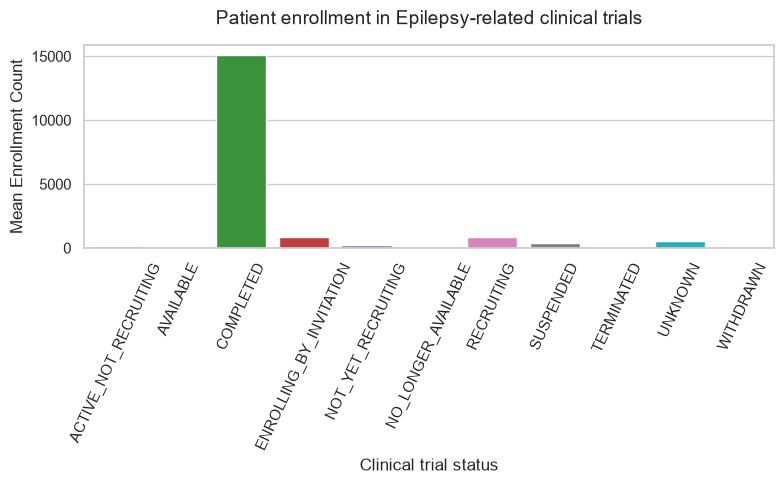

In [23]:
data = (
    clinical_trials_df
        .groupby('overall_status')['enrollment']
        .mean()
        .reset_index()
)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(
    data=data,
    x='overall_status',
    hue='overall_status',
    y='enrollment',
    palette='tab10'
)
plt.title('Patient enrollment in Epilepsy-related clinical trials', pad=15, fontsize=14)
plt.xlabel('Clinical trial status', fontsize=12)
plt.ylabel('Mean Enrollment Count', fontsize=12)
plt.xticks(rotation=65) 
plt.tight_layout();

### Pregunta 2: 
Distribucion de edad de pacientes con reacciones adversas para cada medicamento elegido

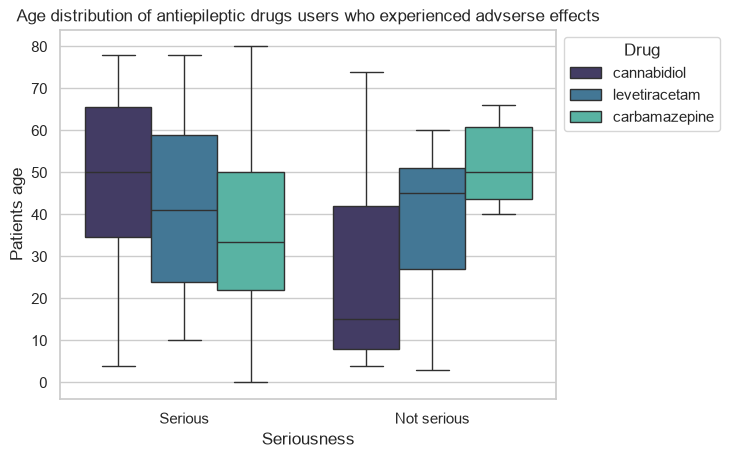

In [24]:
_, ax = plt.subplots()
sns.boxplot(
    data=(
        openfda_df
            [['patient_age', 'serious', 'query_drug']]
        .assign(serious=lambda x: x['serious'].map({1: 'Serious', 2: 'Not serious'}))
    )
    ,
    x='serious',
    hue='query_drug',
    y='patient_age',
    palette='mako',
    dodge=True
)
ax.set_ylabel('Patients age')
ax.set_xlabel('Seriousness')
ax.set_title("Age distribution of antiepileptic drugs users who experienced advserse effects")
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title='Drug');

In [25]:
path='../data/parquet/'
openfda_df.to_parquet(path+'open_fda_antiepileptic_drugs.parquet')
clinical_trials_df.to_parquet(path+'epilepsy_clinical_trials.parquet')
pubmed_df.to_parquet(path+'pubmed_antiepileptic_drugs.parquet')

In [26]:
extractor.print_real_request_stats()

Total requests: 11
	-> Real requests: 0
	-> Handled by cache: 11
